# Inspect topics in the selected-paper abstract clusters

Third notebook in the **selected-paper title-and-abstract comparison**. Run the embedding and clustering notebooks first. Use **Python (batill)**.

Choose any saved partition, inspect its recurring expressions, review two selected papers per cluster, inspect representative and borderline abstracts, and trace supporting text to its PDF spans or approved external source. Clustering is **not rerun here**. No topic names are copied from the larger abstract corpus or old full-PDF analysis. K-means cluster 0 is a valid assigned group.


Previous 287-paper results are archived. The inputs now exclude the five short descriptions; execute the embedding, clustering and topic notebooks in order to produce updated results.


## 1. Load authenticated vectors and the saved partition catalog

This loads the exact catalog exported by **Clustering Elite Papers Abstracts.ipynb**. Missing/stale catalogs produce an explicit error instead of fitting a replacement. The full selection and unavailable-abstract counts are recorded in the source embedding run. All topic statistics use the included title-and-abstract records only.

In [25]:
from pathlib import Path
from html import escape
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/batill').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the batill project.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
from batill.selected_abstract_topics import (
    load_context, partition_catalog, choose_partition, analyse_partition,
    ranked_terms, evidence_table, supporting_papers, export_analysis, search_expression,
)
context = load_context(ROOT)
print(f"Loaded {len(context['papers'])} selected-paper abstracts and {len(context['solutions'])} saved partitions.")
display(partition_catalog(context).style.hide(axis='index').format(precision=3, na_rep='—'))
print('Included text sources:')
display(context['papers'].groupby('abstract_source_kind').size().rename('Papers').to_frame())
print('Short publisher descriptions are excluded from this workflow.')


Loaded 282 selected-paper abstracts and 33 saved partitions.


solution,method,clusters,assigned,unassigned,cosine_silhouette,seed_ARI,resolution,seed
kmeans_k2,K-means,2,282,0,0.086,0.940,—,22
kmeans_k3,K-means,3,282,0,0.104,0.960,—,44
kmeans_k4,K-means,4,282,0,0.085,0.746,—,22
kmeans_k5,K-means,5,282,0,0.078,0.610,—,44
kmeans_k6,K-means,6,282,0,0.080,0.430,—,44
kmeans_k7,K-means,7,282,0,0.054,0.377,—,33
kmeans_k8,K-means,8,282,0,0.060,0.385,—,11
kmeans_k9,K-means,9,282,0,0.056,0.322,—,44
kmeans_k10,K-means,10,282,0,0.049,0.334,—,33
kmeans_k11,K-means,11,282,0,0.044,0.292,—,22


Included text sources:


,Papers
abstract_source_kind,
external_full_abstract,4
pdf_abstract,278


Short publisher descriptions are excluded from this workflow.


## 2. Choose an existing partition

If a preferred partition was recorded in clustering, it is the initial inspection choice. Otherwise `kmeans_k2` is an explicit starting view, not an accepted optimum. Change `SAVED_PARTITION` to any name in the catalog, then rerun this cell and the cells below.

K-means IDs start at 0; Leiden IDs start at 1. Numbers label groups only within this fitted partition. One-community Leiden results remain in the diagnostics but cannot support between-cluster topic contrast.

In [26]:
SAVED_PARTITION = "leiden_r0.7"
# Examples: 'kmeans_k5', 'kmeans_k6', 'leiden_r0.45'. Check actual counts in the catalog.
labels, partition_settings = choose_partition(context, SAVED_PARTITION)
print(json.dumps(partition_settings, indent=2))
print(f"Assigned abstracts: {len(labels)} | Clusters: {len(set(labels))}")

{
  "saved_partition": "leiden_r0.7",
  "method": "Embedding Leiden",
  "seed": 43,
  "resolution": 0.7,
  "quality": 2340.096995313541,
  "seed_ARI": 0.9618179381968769,
  "selection": "highest objective seed within this resolution",
  "clusters": 4,
  "assignment_id": "1ff66d29bc45b6e50d9b98cd7726fc8ccb6b8ab039bcca13260c314f9d0fea68"
}
Assigned abstracts: 282 | Clusters: 4


## 3 Compute the expression evidence

Text is the exact embedded **title plus cleaned abstract**. Lowercasing and
stopword removal are applied; numerical tokens and formatting terms are excluded. Adjacent-word expressions
do not bridge punctuation, stopwords or title/abstract boundaries. Singular/plural forms
and synonyms remain separate.

Two rankings are computed on the same vocabulary:

- **TF-IDF contrast:** mean normalized per-paper TF-IDF inside the cluster minus the
  mean outside. A positive score indicates greater average TF-IDF weight inside.
- **Class-based TF-IDF:** relative pooled frequency within the cluster multiplied by
  `log(1 + mean cluster vocabulary length / corpus term count)`.

Vocabulary terms must occur in at least **3 papers**, and no more than **90%** of the
analysed papers. Ranked terms additionally require a **positive score** and support
in **at least 2 cluster papers**. There is no cluster-percentage cutoff by default:
short abstracts have fewer recurring phrases than full PDFs. This allows the top
16 expressions to include more specific themes. The inside/outside counts still
show how widespread each phrase is; a high rank does not mean broad coverage.

Adjust `MIN_CLUSTER_PAPERS` and `MIN_CLUSTER_FRACTION` below if needed. Setting the
fraction to `0.10` restores the PDF notebook's 10% rule. `TOP_N` remains an upper
limit: fewer rows appear only when fewer eligible terms exist. No terms are added
or removed manually to make a cluster look more coherent.

All records are included, including K-means cluster 0. The table below makes the
analysed population explicit.


In [27]:
MIN_CLUSTER_PAPERS = 2
MIN_CLUSTER_FRACTION = 0.0  # Use 0.10 to restore the PDF notebook's stricter rule.
analysis = analyse_partition(
    context, labels, min_df=3, max_df=0.9,
    min_cluster_papers=MIN_CLUSTER_PAPERS,
    min_cluster_fraction=MIN_CLUSTER_FRACTION,
)
print(f"Analysed papers: {len(analysis['papers'])}; vocabulary: {len(analysis['vocabulary']['terms']):,} terms")
display(analysis['summary'][['cluster', 'papers', 'minimum_support']].rename(columns={
    'cluster': 'Cluster', 'papers': 'Papers', 'minimum_support': 'Minimum supporting papers',
}).style.hide(axis='index'))
if len(analysis['unassigned']):
    display(Markdown('**Unassigned papers excluded from topic contrast:**'))
    display(analysis['unassigned'][['paper_id', 'title']].style.hide(axis='index'))

Analysed papers: 282; vocabulary: 1,655 terms


Cluster,Papers,Minimum supporting papers
1,65,2
2,86,2
3,110,2
4,21,2


### Search a word or expression across clusters

Enter a term below and rerun only this cell to compare its frequency across the
chosen partition. **Papers containing term** counts each paper once; **total
occurrences** includes every repetition. The percentage uses the size of each
cluster; occurrences per paper includes papers with zero matches.

Search is case-insensitive and matches whole words in sequence. Hyphens are treated
as spaces; singular/plural forms are separate. Phrases cannot cross sentence or
title/abstract boundaries. Unlike ranked vocabulary, manual search also accepts rare
terms, stopwords, numbers and phrases longer than two words, without support filters.
Both title and abstract are searched. Raw occurrence counts are sensitive to text
length; paper-level prevalence counts each paper only once.

In [28]:
SEARCH_TERM = 'private equity'
search_results = search_expression(analysis, SEARCH_TERM)
print('Search:', search_results.attrs['normalized_query'])
display(search_results.style.hide(axis='index').format({
    'Papers containing term (%)': '{:.1f}', 'Occurrences per paper': '{:.2f}',
}))

Search: private equity


Cluster,Papers in cluster,Papers containing term,Papers containing term (%),Total occurrences,Occurrences per paper
1,65,52,80.0,156,2.40
2,86,52,60.5,123,1.43
3,110,99,90.0,261,2.37
4,21,21,100.0,80,3.81


## 4 Compare the clusters without naming them

Each cluster receives its own small table. Start with two-word expressions, then
optionally switch `TERM_KIND` to `word`. Rankings are computed separately for these
display types without changing their scores. Change `RANKING` to compare methods.

| Column | Meaning |
|---|---|
| Score | Value under the selected ranking; scores from different ranking methods are not on the same scale. |
| Inside / outside papers | Number of papers containing the term at least once, divided by the corresponding population. |
| Inside / outside % | Paper-level prevalence, regardless of repetition within a paper. |
| Gap (pp) | Inside prevalence minus outside prevalence, in percentage points. |

A contrast score and a prevalence gap measure different things: TF-IDF also considers
repetition and document normalization. A positive contrast need not imply a positive
prevalence gap. These are **descriptive statistics, not significance tests**.

In [29]:
RANKING = 'tfidf_contrast'       # Or 'c_tf_idf'.
TERM_KIND = 'expression'        # Or 'word'.
TOP_N = 16                     # Up to 16 eligible terms per cluster.

def show_terms(rows):
    if rows.empty:
        print('No terms meet the support and positive-score thresholds.')
        return
    display(evidence_table(rows).style.hide(axis='index').format({
        'Score': '{:.5f}', 'Inside %': '{:.1f}', 'Outside %': '{:.1f}', 'Gap (pp)': '{:+.1f}',
    }))

for row in analysis['summary'].itertuples():
    display(Markdown(f'### Cluster {row.cluster} — {row.papers} papers'))
    show_terms(ranked_terms(analysis, row.cluster, RANKING, TERM_KIND, TOP_N))

### Cluster 1 — 65 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
private firms,0.02527,11,65,1,217,16.9,0.5,+16.5
going private,0.02088,6,65,4,217,9.2,1.8,+7.4
private firm,0.01407,4,65,0,217,6.2,0.0,+6.2
pe backed,0.01350,6,65,3,217,9.2,1.4,+7.8
portfolio firms,0.01331,5,65,1,217,7.7,0.5,+7.2
private decisions,0.01287,3,65,0,217,4.6,0.0,+4.6
pe investors,0.01279,7,65,7,217,10.8,3.2,+7.5
backed firms,0.01154,5,65,1,217,7.7,0.5,+7.2
public firms,0.01137,6,65,4,217,9.2,1.8,+7.4
equity backed,0.01115,5,65,5,217,7.7,2.3,+5.4


### Cluster 2 — 86 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
leveraged buyouts,0.04682,32,86,2,196,37.2,1.0,+36.2
leveraged buyout,0.01765,12,86,4,196,14.0,2.0,+11.9
post buyout,0.01749,11,86,1,196,12.8,0.5,+12.3
management buyouts,0.01713,8,86,0,196,9.3,0.0,+9.3
operating performance,0.01609,10,86,0,196,11.6,0.0,+11.6
secondary buyouts,0.01563,6,86,0,196,7.0,0.0,+7.0
capital structure,0.01318,7,86,2,196,8.1,1.0,+7.1
equity buyouts,0.01233,8,86,2,196,9.3,1.0,+8.3
target firms,0.01145,8,86,2,196,9.3,1.0,+8.3
public companies,0.00905,6,86,3,196,7.0,1.5,+5.4


### Cluster 3 — 110 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
venture capital,0.02975,32,110,8,172,29.1,4.7,+24.4
equity funds,0.02114,21,110,8,172,19.1,4.7,+14.4
buyout funds,0.01880,17,110,1,172,15.5,0.6,+14.9
private equity,0.01601,99,110,125,172,90.0,72.7,+17.3
cash flows,0.01482,12,110,2,172,10.9,1.2,+9.7
institutional investors,0.01394,10,110,1,172,9.1,0.6,+8.5
fund performance,0.01369,12,110,0,172,10.9,0.0,+10.9
equity returns,0.01307,10,110,1,172,9.1,0.6,+8.5
capital funds,0.01303,10,110,0,172,9.1,0.0,+9.1
limited partners,0.01268,11,110,1,172,10.0,0.6,+9.4


### Cluster 4 — 21 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
nursing home,0.05040,7,21,0,261,33.3,0.0,+33.3
nursing homes,0.04993,6,21,0,261,28.6,0.0,+28.6
pe ownership,0.04856,5,21,4,261,23.8,1.5,+22.3
pe owned,0.04162,6,21,0,261,28.6,0.0,+28.6
equity acquisition,0.03791,6,21,1,261,28.6,0.4,+28.2
health care,0.03489,4,21,0,261,19.0,0.0,+19.0
acquired hospitals,0.03193,4,21,0,261,19.0,0.0,+19.0
percentage points,0.02433,4,21,8,261,19.0,3.1,+16.0
equity acquired,0.02211,4,21,0,261,19.0,0.0,+19.0
financial performance,0.02098,3,21,1,261,14.3,0.4,+13.9


## 5 Validate the cluster content with two representative papers

The supervisor's request — *“Die Cluster sollten zusätzlich anhand repräsentativer
Arbeiten inhaltlich validiert werden”* — is addressed for the saved elite-abstract
**Leiden partition at resolution 0.7**, containing **282 papers in four clusters**.
Each pair comes from that exact partition. Cluster numbers are retained; the focus
phrases are review prompts rather than newly assigned cluster names.

| Cluster | Requested review focus | Papers |
|---|---|---:|
| 1 | Going private: a PE firm acquiring a listed firm | 65 |
| 2 | Leveraged and management buyouts: the transaction process | 86 |
| 3 | Fund performance across evaluation criteria | 110 |
| 4 | Health care and nursing homes | 21 |

The selections combine substantive reading with **abstract-embedding diagnostics**.
Each paper must address the requested subject and PE funds, PE ownership or the
sponsor-backed buyout model. A keyword match alone is insufficient. The choices,
rationales and exact excerpts are recorded in `configs/elite_abstract_cluster_examples.json`
and checked against the saved vectors, memberships, included texts and source files.

**Reading the evidence:** centrality rank orders each paper by its mean cosine
similarity to the other title-and-abstract vectors in its cluster (rank 1 is most
central). Cosine silhouette describes its separation from other clusters. These
metrics are context for the content judgment, not the selection rule.

Each paper has two supporting passages and an expandable full included abstract.
Of the 16 passages, **13 are excerpts from the included cleaned abstracts** and
**3 are supplementary PDF passages** explaining acquisition or management mechanisms.
Supplementary passages are clearly labelled and **do not enter the abstract vectors**.
Abstract offsets refer to the cleaned abstract; recorded PDF spans describe its source.
Kaplan and Strömberg's abstract comes from an approved external full-abstract record
and has no claimed PDF abstract spans. PDF and cached-source links support inspection.

The examples validate particular strands rather than proving whole-cluster uniformity.
Cluster 1 also contains governance and disclosure studies. In Cluster 2, the overview
covers PE/LBOs and the second paper specifically covers MBOs; not all LBOs are
management-led. Scope notes also identify related studies, historical samples and OCR
artefacts. Boundary and random examples in the next section can challenge the interpretation.

The eight selections, sixteen passages and diagnostics for all 282 abstracts are
saved automatically under `reports/elite_abstract_cluster_examples/<review-checksum>/`.
Other saved partitions require their own content review.


In [30]:
from importlib import reload
from urllib.parse import quote
import batill.elite_abstract_cluster_examples as elite_examples
reload(elite_examples)
from batill.storage import read_json

REVIEW_CONFIG = ROOT / 'configs/elite_abstract_cluster_examples.json'
representative_review = read_json(REVIEW_CONFIG)
if partition_settings.get('saved_partition') != representative_review['solution']:
    display(Markdown('These content-reviewed examples belong to **saved `leiden_r0.7`**. '
                     'Select that partition in section 2 and rerun to display them; '
                     'other partitions need a separate content review.'))
else:
    representatives, representative_passages, representative_diagnostics = elite_examples.representative_papers(
        context, analysis, partition_settings, representative_review,
    )
    for cluster in sorted(representatives.cluster.unique()):
        focus = representative_review['focus'][str(cluster)]
        display(Markdown(f'### Cluster {cluster}\n\n**Requested focus:** {focus}'))
        for paper in representatives.loc[representatives.cluster.eq(cluster)].itertuples():
            pdf_path = ROOT / 'data/pdfs' / paper.source_filename
            if not pdf_path.is_file():
                raise FileNotFoundError(f'Missing reviewed PDF: {pdf_path}')
            pdf_url = quote('data/pdfs/' + paper.source_filename, safe='/')
            source_url = quote(paper.abstract_source_path, safe='/')
            if paper.abstract_source_kind == 'external_full_abstract':
                origin = (f'Approved external full abstract: '
                          f'<a href="{escape(paper.abstract_source_url, quote=True)}" target="_blank">publisher source</a>. '
                          'No PDF abstract spans are claimed.')
            else:
                pages = sorted({span['page'] for span in json.loads(paper.abstract_spans)})
                page_links = ', '.join(f'<a href="{pdf_url}#page={page}" target="_blank">{page}</a>' for page in pages)
                origin = f'PDF-extracted abstract; source pages: {page_links}.'
            diagnostics = (f'Abstract-vector centrality rank {paper.centrality_rank}/{paper.cluster_papers}; '
                           f'mean within-cluster cosine {paper.mean_within_cluster_cosine:.3f}; '
                           f'cosine silhouette {paper.cosine_silhouette:+.3f}')
            passages_html = []
            for passage in representative_passages.loc[representative_passages.paper_id.eq(paper.paper_id)].itertuples():
                if passage.source_field == 'pdf_context':
                    page = int(passage.page)
                    location = (f'<strong>Supplementary PDF context (not embedded)</strong> — '
                                f'<a href="{pdf_url}#page={page}" target="_blank">PDF page {page}</a>; '
                                f'block {escape(passage.block_id)}; block characters '
                                f'{passage.excerpt_start}–{passage.excerpt_end}')
                else:
                    location = (f'<strong>Included cleaned abstract</strong> — characters '
                                f'{passage.excerpt_start}–{passage.excerpt_end}; '
                                f'{escape(passage.source_kind)}')
                passages_html.append(f'<p>{location}</p><blockquote style="white-space:pre-wrap">'
                                     f'{escape(passage.excerpt)}</blockquote>')
            display(HTML(
                '<div style="border-left:3px solid #46758c;padding:0 1em;margin:1em 0 1.6em">'
                f'<h4>{escape(paper.paper_id)} · {escape(paper.citation)}<br>'
                f'<a href="{pdf_url}" target="_blank">{escape(paper.title)}</a></h4>'
                f'<p><strong>Role in this pair:</strong> {escape(paper.role)}</p>'
                f'<p><strong>Why selected:</strong> {escape(paper.why_representative)}</p>'
                f'<p><strong>Private-equity relevance:</strong> {escape(paper.private_equity_focus)}</p>'
                f'<p><strong>Diagnostic context:</strong> {escape(diagnostics)}</p>'
                f'<p><strong>Scope and interpretation:</strong> {escape(paper.scope_note)}</p>'
                '<details><summary>Read the two supporting passages</summary>'
                + ''.join(passages_html) + '</details>'
                '<details><summary>Full included abstract and source</summary>'
                f'<p>{origin} <a href="{source_url}" target="_blank">Cached source record</a></p>'
                f'<p style="white-space:pre-wrap">{escape(paper.abstract)}</p>'
                f'<details><summary>Recorded abstract source spans</summary>'
                f'<pre style="white-space:pre-wrap">{escape(paper.abstract_spans)}</pre></details>'
                '</details></div>'
            ))
    representative_export = elite_examples.export_representative_papers(
        context, REVIEW_CONFIG, representative_review, representatives,
        representative_passages, representative_diagnostics, partition_settings,
    )
    print(f'Saved {len(representatives)} examples and {len(representative_passages)} passages:')
    print(representative_export)


### Cluster 1

**Requested focus:** going private: PE acquisition of a listed firm

### Cluster 2

**Requested focus:** leveraged buyouts and management buyouts: process

### Cluster 3

**Requested focus:** fund performance across evaluation criteria

### Cluster 4

**Requested focus:** health care and nursing homes

Saved 8 examples and 16 passages:
/Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/reports/elite_abstract_cluster_examples/b16e43169004e13e


## 6 Inspect one cluster more closely

Choose a numeric cluster ID. Both rankings appear below, followed by a coverage plot
for the ranking selected above. Agreement between rankings is useful context, but both
use the same underlying text and are not independent validation.

In [31]:
CLUSTER = int(min(analysis['labels']))  # Replace with a cluster ID from the table.
DETAIL_TOP_N = 12
if CLUSTER not in set(analysis['labels']):
    raise ValueError(f"Choose one of {sorted(set(analysis['labels']))}")
for method, title in [('tfidf_contrast', 'TF-IDF contrast'), ('c_tf_idf', 'Class-based TF-IDF')]:
    display(Markdown(f'### Cluster {CLUSTER}: {title}'))
    show_terms(ranked_terms(analysis, CLUSTER, method, TERM_KIND, DETAIL_TOP_N))

### Cluster 1: TF-IDF contrast

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
private firms,0.02527,11,65,1,217,16.9,0.5,+16.5
going private,0.02088,6,65,4,217,9.2,1.8,+7.4
private firm,0.01407,4,65,0,217,6.2,0.0,+6.2
pe backed,0.01350,6,65,3,217,9.2,1.4,+7.8
portfolio firms,0.01331,5,65,1,217,7.7,0.5,+7.2
private decisions,0.01287,3,65,0,217,4.6,0.0,+4.6
pe investors,0.01279,7,65,7,217,10.8,3.2,+7.5
backed firms,0.01154,5,65,1,217,7.7,0.5,+7.2
public firms,0.01137,6,65,4,217,9.2,1.8,+7.4
equity backed,0.01115,5,65,5,217,7.7,2.3,+5.4


### Cluster 1: Class-based TF-IDF

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
private equity,0.06845,52,65,172,217,80.0,79.3,+0.7
going private,0.02288,6,65,4,217,9.2,1.8,+7.4
private firms,0.01988,11,65,1,217,16.9,0.5,+16.5
equity firms,0.01826,9,65,18,217,13.8,8.3,+5.6
private firm,0.01392,4,65,0,217,6.2,0.0,+6.2
pe investors,0.01372,7,65,7,217,10.8,3.2,+7.5
pe firms,0.01128,8,65,15,217,12.3,6.9,+5.4
equity backed,0.01118,5,65,5,217,7.7,2.3,+5.4
owned firms,0.01074,3,65,1,217,4.6,0.5,+4.2
portfolio firms,0.01074,5,65,1,217,7.7,0.5,+7.2


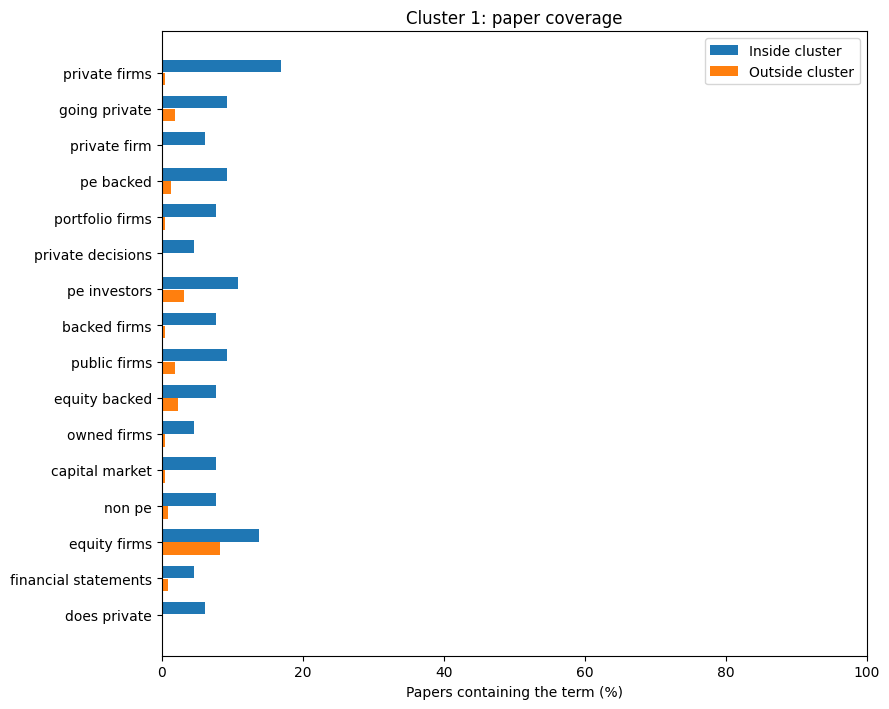

In [32]:
selected_terms = ranked_terms(analysis, CLUSTER, RANKING, TERM_KIND, TOP_N)
if not selected_terms.empty:
    plot_rows = selected_terms.iloc[::-1]
    y = np.arange(len(plot_rows))
    fig, ax = plt.subplots(figsize=(9, max(3, 0.45 * len(plot_rows))))
    ax.barh(y + 0.18, 100 * plot_rows.inside_prevalence, height=0.35, label='Inside cluster')
    ax.barh(y - 0.18, 100 * plot_rows.outside_prevalence, height=0.35, label='Outside cluster')
    ax.set(yticks=y, yticklabels=plot_rows.term, xlim=(0, 100),
           xlabel='Papers containing the term (%)', title=f'Cluster {CLUSTER}: paper coverage')
    ax.legend()
    fig.tight_layout()
    plt.show()

### Paper examples and possible counterexamples

Three representatives have the highest average cosine similarity to their cluster's
other papers. Two boundary examples have the lowest cosine silhouette. Up to two
further papers are sampled with a fixed seed. A paper may have more than one role.

Expand a paper to inspect its saved abstract excerpt and full cleaned abstract.
Excerpt offsets refer to characters in that abstract. Excerpts are usually selected
around highly ranked terms. A low silhouette is not evidence that a paper should
be excluded.


In [33]:
review = analysis['examples'].loc[analysis['examples'].cluster == CLUSTER]
display(review[['paper_id', 'title', 'selection', 'cosine_silhouette']].style.hide(axis='index')
        .format({'cosine_silhouette': '{:.3f}'}).set_properties(**{'white-space': 'normal'}))
for paper in review.itertuples():
    heading = escape(f'{paper.paper_id} — {paper.title} ({paper.selection})')
    location = escape(f'Abstract characters {paper.excerpt_start}–{paper.excerpt_end}; '
                      f'selected term: {paper.term or "none"}')
    display(HTML(f'<details><summary>{heading}</summary><p>{location}</p>'
                 f'<p style="white-space:pre-wrap">{escape(paper.excerpt)}</p>'
                 f'<details><summary>Full cleaned abstract</summary>'
                 f'<p style="white-space:pre-wrap">{escape(paper.abstract)}</p>'
                 f'</details></details>'))

example_ids = analysis['examples'].paper_id.unique()
display(context['papers'].loc[context['papers'].paper_id.isin(example_ids),
        ['paper_id', 'abstract_source_kind', 'abstract_word_count', 'abstract_source_url']])


paper_id,title,selection,cosine_silhouette
P037,The Effects of Public and Private Equity Markets on Firm Behavior,representative,0.121
P041,Private Equity Investments and Disclosure Policy,representative,0.125
P101,Private Equity and Corporate Governance: Retrospect and Prospect,representative,0.034
P040,The Operational Consequences of Private Equity Buyouts: Evidence from the Restaurant Industry,boundary,-0.054
P303,Specialization and performance in private equity: Evidence from the hotel industry,boundary,-0.019
P172,Was there too little entry during the Dot Com Era?,random,0.039
P135,"Private equity, investment and financial constraints: firm-level evidence for France and the United Kingdom",random,0.055


,paper_id,abstract_source_kind,abstract_word_count,abstract_source_url
20,P021,pdf_abstract,93,
21,P022,pdf_abstract,128,
36,P037,pdf_abstract,130,
39,P040,pdf_abstract,90,
40,P041,pdf_abstract,189,
59,P061,pdf_abstract,453,
66,P069,pdf_abstract,543,
89,P094,pdf_abstract,104,
95,P101,pdf_abstract,402,
111,P117,pdf_abstract,191,


## 7 Trace a specific expression to its papers

Copy an exact term from a table into `EXPRESSION`, or leave it as `None` to use the
first term in the selected cluster/ranking. Support uses the whole-word search from section 3, including hyphen normalization;
ranked expressions use the same contiguous wording. Each paper counts once for coverage;
the occurrence count is provided separately. Supporting papers outside the cluster
help distinguish a specific theme from vocabulary shared across the literature.

In [34]:
EXPRESSION = None               # For example, copy an expression from your table.
SUPPORT_ROWS = 20              # Display limit only; export includes every supporting paper.
selected_terms = ranked_terms(analysis, CLUSTER, RANKING, TERM_KIND, TOP_N)
selected_expression = EXPRESSION or (selected_terms.iloc[0].term if len(selected_terms) else None)
support = None
if selected_expression is None:
    print('No eligible term in this view. Choose another cluster or term kind.')
else:
    support = supporting_papers(analysis, selected_expression, CLUSTER)
    n_inside = int((analysis['labels'] == CLUSTER).sum())
    print(f'Expression: {selected_expression}')
    print(f'Inside: {support.inside.sum()}/{n_inside}; outside: {(~support.inside).sum()}/{len(analysis["papers"]) - n_inside}')
    for inside, title in [(True, 'Inside cluster'), (False, 'Outside cluster')]:
        group = support.loc[support.inside == inside]
        display(Markdown(f'### {title}: showing {min(SUPPORT_ROWS, len(group))} of {len(group)} supporting papers'))
        display(group[['paper_id', 'title', 'cluster', 'occurrences', 'source_field']].head(SUPPORT_ROWS)
                .style.hide(axis='index').set_properties(**{'white-space': 'normal'}))

Expression: private firms
Inside: 11/65; outside: 1/217


### Inside cluster: showing 11 of 11 supporting papers

paper_id,title,cluster,occurrences,source_field
P024,The separation of ownership and control and corporate tax avoidance,1,2,abstract
P027,Do Public Financial Statements Influence Private Equity and Venture Capital Financing?,1,3,abstract
P036,Size management by European private firms to minimize proprietary costs of disclosure,1,2,title
P054,Company Websites: A New Measure of Disclosure,1,1,abstract
P097,Investing with the Government: A Field Experiment in China,1,2,abstract
P124,Do Going-Private Transactions Affect Plant Efficiency and Investment?,1,1,abstract
P140,The Deregulation of the Private Equity Markets and the Decline in IPOs,1,1,abstract
P145,Regulatory costs of being public: Evidence from bunching estimation,1,1,abstract
P205,ALL CLEAR FOR TAKEOFF: EVIDENCE FROM AIRPORTS ON THE EFFECTS OF INFRASTRUCTURE PRIVATIZATION,1,1,abstract
P231,Earnings Quality and Ownership Structure: The Role of Private Equity Sponsors,1,1,abstract


### Outside cluster: showing 1 of 1 supporting papers

paper_id,title,cluster,occurrences,source_field
P093,Sources of Value Creation in Private Equity Buyouts of Private Firms,2,3,title


In [35]:
PAPER_ID = None                 # Copy a paper_id above, or inspect the first supporting paper.
if support is not None and len(support):
    inspected = support.iloc[0] if PAPER_ID is None else support.set_index('paper_id').loc[PAPER_ID]
    display(Markdown(f'**Source field: {inspected.source_field}**'))
    display(HTML(f'<p>{escape(inspected.title)}</p><pre style="white-space:pre-wrap">'
                 f'{escape(inspected.passage)}</pre>'))

**Source field: abstract**

### Trace a paper to its actual abstract source

Choose a Pxxx ID to see the exact included text, source type and provenance. PDF abstracts retain their page/block/character spans. Approved external full abstracts link to their source and cached record, with checksums; they are not presented as PDF-extracted text. Short publisher descriptions are excluded. The preparation audit records unavailable abstracts and excluded descriptions.

In [36]:
TRACE_PAPER_ID = analysis['papers'].iloc[0].paper_id
traced = context['papers'].set_index('paper_id').loc[TRACE_PAPER_ID]
print(TRACE_PAPER_ID, traced.title)
print('PDF identity:', traced.source_filename)
print('Abstract source type:', traced.abstract_source_kind)
print('Source URL:', traced.abstract_source_url or 'Cached PDF extraction')
print('Source record ID:', traced.abstract_source_record_id)
print('Cached source:', traced.abstract_source_path)
print('Review:', traced.review_reason)
print('Title source:', traced.title_source, '| Title spans:', traced.title_spans)
from batill.storage import file_hash
if file_hash(ROOT / traced.abstract_source_path) != traced.abstract_source_sha256:
    raise ValueError('Abstract source changed since embedding; regenerate preparation before tracing evidence.')
if traced.abstract_source_kind == 'pdf_abstract':
    print('PDF source spans:', traced.abstract_spans)
else:
    print('External source text; no PDF abstract spans are claimed.')
display(HTML(f'<pre style="white-space:pre-wrap">{escape(traced.abstract)}</pre>'))


P001 ESG Disclosures in the Private Equity Industry
PDF identity: Abraham et al. - 2024 - ESG Disclosures in the Private Equity Industry.pdf
Abstract source type: pdf_abstract
Source URL: Cached PDF extraction
Source record ID: 
Cached source: outputs/corpus/extraction/documents/b0a9d3c2ce641e5878e272ed90e94645b3ea8b4acfdbf436d7693433ede578ad.json
Review: Abstract continues from page 1 to page 2 across affiliations and a publisher notice. Joined only its two prose blocks, stopping before JEL codes and keywords.
Title source: pdf_embedding_manifest | Title spans: []
PDF source spans: [{"block_id": "/page/0/Text/8", "page": 1, "start": 0, "end": 151}, {"block_id": "/page/1/Text/2", "page": 2, "start": 0, "end": 711}]


## 8 Save evidence for your interpretation

Set `SAVE_RESULTS = True` when you want a permanent record. Each export creates a new
folder under `outputs/selected_abstracts/topic_analysis`; previous evidence is never replaced.

It contains full eligible word/expression rankings for both methods, cluster sizes,
membership, review papers with excerpts and full abstracts, supporting papers for
the selected expression, and a manifest of parameters, input hashes and software versions.
Scores and proportions are saved at full precision. Plot display is not required for reproduction.

When you later name a cluster, record which expressions and papers support the name,
which papers challenge it, and the exported run folder. Inspect broad methodological vocabulary, synonyms and mixed subject matter before
interpreting a ranking. A descriptive label should remain open to revision.

In [37]:
SAVE_RESULTS = False
if SAVE_RESULTS:
    exported = export_analysis(analysis, context, partition_settings, support=support,
        display_settings=dict(cluster=CLUSTER, ranking=RANKING, kind=TERM_KIND,
                              top_n=TOP_N, detail_top_n=DETAIL_TOP_N, expression=selected_expression))
    print('Saved evidence:', exported)
else:
    print('Full expression-evidence export disabled. Set SAVE_RESULTS = True to save it.')

Full expression-evidence export disabled. Set SAVE_RESULTS = True to save it.
